#### Dataset Title: Football Players Data
#### Dataset source link: https://www.kaggle.com/datasets/maso0dahmed/football-players-data/data

#### Dataset features description:

| Column | Description | Column | Description | Column | Description |
|---|---|---|---|---|---|
| name | Name of the player. | body_type | Player's body type. | ball_control | Rating for ball control. |
| full_name | Full name of the player. | release_clause_euro | Release clause of the player in euros. | acceleration | Rating for acceleration. |
| birth_date | Date of birth of the player. | national_team | National team of the player. | sprint_speed | Rating for sprint speed. |
| age | Age of the player. | national_rating | Rating in the national team. | agility | Rating for agility. |
| height_cm | Player's height in centimeters. | national_team_position | Position in the national team. | reactions | Rating for reactions. |
| weight_kgs | Player's weight in kilograms. | national_jersey_number | Jersey number in the national team. | balance | Rating for balance. |
| positions | Positions the player can play. | crossing | Rating for crossing ability. | shot_power | Rating for shot power. |
| nationality | Player's nationality. | finishing | Rating for finishing ability. | jumping | Rating for jumping. |
| overall_rating | Overall rating of the player in FIFA. | heading_accuracy | Rating for heading accuracy. | stamina | Rating for stamina. |
| potential | Potential rating of the player in FIFA. | short_passing | Rating for short passing ability. | strength | Rating for strength. |
| value_euro | Market value of the player in euros. | volleys | Rating for volleys. | long_shots | Rating for long shots. |
| wage_euro | Weekly wage of the player in euros. | dribbling | Rating for dribbling. | aggression | Rating for aggression. |
| preferred_foot | Player's preferred foot. | curve | Rating for curve shots. | interceptions | Rating for interceptions. |
| international_reputation(1-5) | International reputation rating from 1 to 5. | freekick_accuracy | Rating for free kick accuracy. | positioning | Rating for positioning. |
| weak_foot(1-5) | Rating of the player's weaker foot from 1 to 5. | long_passing | Rating for long passing. | vision | Rating for vision. |
| skill_moves(1-5) | Skill moves rating from 1 to 5. | penalties | Rating for penalties. | marking | Rating for marking. |
| composure | Rating for composure. | standing_tackle | Rating for standing tackle. | sliding_tackle | Rating for sliding tackle. |

### Imports
---

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from celery.utils.term import colored
from matplotlib.lines import lineStyles

In [47]:
data = pd.read_csv('../data/fifa_players.csv')
data

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,...,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,...,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,...,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,...,58,38,15,54,52,50,53,16,18,17


In [48]:
# dataset dimensions
data.shape

(17954, 51)

In [49]:
# Features type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

In [50]:
data.isna().sum()

name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                         255
wage_euro                          246
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro               1837
national_team                    17097
national_rating                  17097
national_team_position           17097
national_jersey_number           17097
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing            

In [51]:
# Players who do not play for the national team of the country where they were born.

# One part of the analysis will include a profile of players who may be underrated based on their sporting attributes
# and are not included in the national team.

# The feature `national_rating` has the same number of missing values as the feature `national_team`.
# This most likely means that `national_rating` is calculated only for players who are included in their national teams.
data[data['national_team'].isna()]

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87
16,M. Škriniar,Milan Škriniar,2/11/1995,24,187.96,79.8,CB,Slovakia,86,93,...,30,86,86,30,57,56,81,92,89,84
17,Fernandinho,Fernando Luiz Rosa,5/4/1985,33,152.40,67.1,CDM,Brazil,87,87,...,78,87,89,70,75,61,79,87,86,80
18,G. Higuaín,Gonzalo Gerardo Higuaín,12/10/1987,31,185.42,88.9,ST,Argentina,87,87,...,80,50,20,92,74,70,86,35,22,18
19,I. Rakitić,Ivan Rakitić,3/10/1988,30,182.88,78.0,"CM,CDM",Croatia,87,87,...,87,67,81,80,86,82,86,76,75,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,...,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,...,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,...,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,...,58,38,15,54,52,50,53,16,18,17


There are also other missing values in some of the features in the dataset, but their number is not very large.

During the data preprocessing stage, we will decide how to handle them. One possible approach is to fill them with the average wage of the team the player belongs to.

At this stage, no action will be taken.

### Feature analysis
---

#### 1. Age analysis

In [52]:
# Descriptive statistics for player age
data['age'].describe()

count    17954.000000
mean        25.565445
std          4.705708
min         17.000000
25%         22.000000
50%         25.000000
75%         29.000000
max         46.000000
Name: age, dtype: float64

In [53]:
# No missing values
data['age'].isna().sum()

np.int64(0)

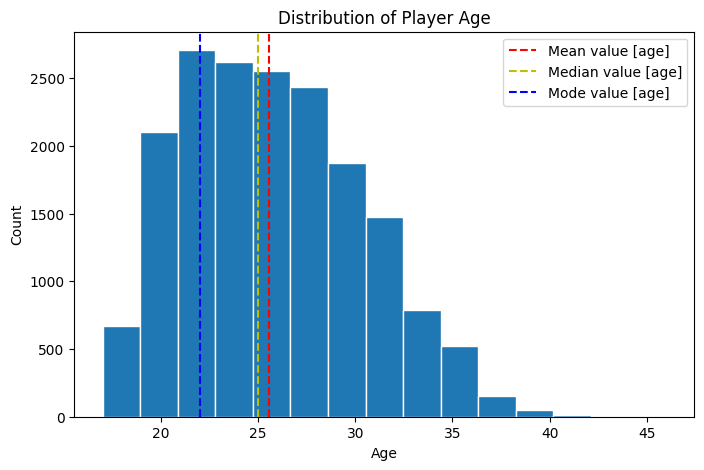

In [54]:
plt.figure(figsize=(8, 5))
mean_age = data['age'].mean()
meadian_age = data['age'].median()
mode_age = data['age'].mode().iloc[0]

plt.hist(data['age'], bins=15, edgecolor='white')
plt.axvline(mean_age, color='r', linestyle = '--', label='Mean value [age]')
plt.axvline(meadian_age, color='y', linestyle = '--', label='Median value [age]')
plt.axvline(mode_age, color='b', linestyle = '--', label='Mode value [age]')

plt.title('Distribution of Player Age')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

In [55]:
mode_age

np.int64(22)

Most football players are concentrated around the age of 22.

In [56]:
meadian_age

np.float64(25.0)

In [57]:
mean_age

np.float64(25.56544502617801)

The mean and median age are very close, which suggests that the age distribution is relatively balanced and not strongly affected by extreme values.

#### 2. height_cm analysis

In [58]:
data['height_cm'].describe()

count    17954.000000
mean       174.946921
std         14.029449
min        152.400000
25%        154.940000
50%        175.260000
75%        185.420000
max        205.740000
Name: height_cm, dtype: float64

In [59]:
# No missing values
data['height_cm'].isna().sum()

np.int64(0)

In [62]:
# Here, we examine the players’ height and whether lower height could be related to younger age.
# However, we can see that even the shortest football players are between 17 and 42 years old.
# These physical characteristics are not always a leading factor,
# but it is certainly important to analyze this indicator in order to understand what is typical.
data[data['height_cm'] < 160]['age'].describe()

count    4515.000000
mean       25.375194
std         4.707351
min        17.000000
25%        22.000000
50%        25.000000
75%        29.000000
max        42.000000
Name: age, dtype: float64

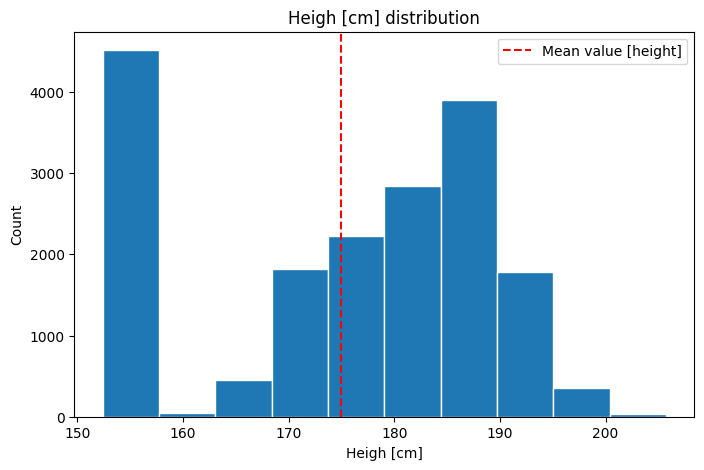

In [74]:
plt.figure(figsize=(8, 5))
mean_height = data['height_cm'].mean()


plt.hist(data['height_cm'], bins=10, edgecolor='white')
plt.axvline(mean_height, color='r', linestyle = '--', label='Mean value [height]')

plt.xlabel('Heigh [cm]')
plt.ylabel('Count')
plt.title('Heigh [cm] distribution')
plt.legend()
plt.show()